In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import contextily as ctx
import folium
from shapely.geometry import Polygon
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import shapely

In [2]:
def limit_gdf(base_gdf: gpd.GeoDataFrame, limiting_gdf: gpd.GeoDataFrame):
    limiting_geom = limiting_gdf.geometry.iloc[0]
    limited_gdf = base_gdf[base_gdf.geometry.intersects(limiting_geom)].copy()
    #limited_gdf = limited_gdf.reset_index(drop=True)
    #print("Shape of limited gdf: ", limited_gdf.shape)
    #print(filtered_buildings_gdf.head())
    return limited_gdf

def plot(base_gdf: gpd.GeoDataFrame, border_gdf: gpd.GeoDataFrame, other_gdf: gpd.GeoDataFrame = None) -> None:
    fig, ax = plt.subplots(figsize=(12, 12))

    base_gdf.plot(
        #column="usage",
        #legend=True,
        #categorical=True,
        color="grey",
        ax=ax
    )
    
    border_gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=2
    )

    if other_gdf is not None:
        other_gdf.plot(
            ax=ax,
            color="tab:orange",
            alpha=0.5,
            #color="none",          # no solid fill
            edgecolor="black",
            linewidth=0.5,
            #hatch="xxxx"
        )

    plt.title("No Title")
    plt.show()

default_bbox = [[10.071450882096563, 53.57343719771864],
               [10.078282200812708, 53.57582089436743],
               [10.086978353249249, 53.57780085497406],
               [10.088500780178016, 53.57786434031859],
               [10.08968943613927, 53.57528776626812],
               [10.090770539267197, 53.57544358156409],
               [10.09161951641922, 53.57351782519276],
               [10.081990170144394, 53.57132713390438],
                [10.07602700765947, 53.571645156140086],
                [10.07573490367003, 53.5721943741919],
                [10.072668065541466, 53.57226654319956]]

In [3]:
def _candidate_pairs(base: gpd.GeoDataFrame, other: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """All (base, other) pairs whose polygons touch at all, via spatial index."""
    base = base[["geometry"]].copy()
    other = other[["geometry"]].copy()
    base["_base_idx"] = base.index
    other["_other_idx"] = other.index
    return gpd.sjoin(base, other, how="inner", predicate="intersects")[["_base_idx", "_other_idx"]]


def _score_pairs(base: gpd.GeoDataFrame, other: gpd.GeoDataFrame, pairs: gpd.GeoDataFrame, mode: str) -> gpd.GeoDataFrame:
    if pairs.empty:
        return pairs.assign(score=[])
    base_geom = base.geometry.loc[pairs["_base_idx"]].values
    other_geom = other.geometry.loc[pairs["_other_idx"]].values
    inter_area = shapely.area(shapely.intersection(base_geom, other_geom))
    if mode == "iou":
        union_area = shapely.area(shapely.union(base_geom, other_geom))
        score = np.where(union_area > 0, inter_area / union_area, 0.0)
    elif mode == "coverage":
        base_area = shapely.area(base_geom)
        score = np.where(base_area > 0, inter_area / base_area, 0.0)
    else:
        raise ValueError(f"Unknown mode: {mode}")
    # floating-point noise can push coverage/IoU a hair past 1.0 for near-exact matches
    return pairs.assign(score=np.clip(score, 0.0, 1.0))


def _best_match(base: gpd.GeoDataFrame, other: gpd.GeoDataFrame, mode: str, min_score: float) -> gpd.GeoDataFrame:
    pairs = _candidate_pairs(base, other)
    scored = _score_pairs(base, other, pairs, mode)
    scored = scored[scored["score"] >= min_score]
    return scored.sort_values("score", ascending=False).drop_duplicates("_base_idx", keep="first").reset_index(drop=True)


def best_iou_match(base: gpd.GeoDataFrame, other: gpd.GeoDataFrame, min_iou: float = 0.3) -> gpd.GeoDataFrame:
    """Match each base geometry to the other geometry with highest intersection-over-union.

    Use this for datasets that are ~1:1 with the base (e.g. two independently
    digitized building-outline sources for the same buildings).
    """
    return _best_match(base, other, mode="iou", min_score=min_iou)


def best_coverage_match(base: gpd.GeoDataFrame, other: gpd.GeoDataFrame, min_coverage: float = 0.3) -> gpd.GeoDataFrame:
    """Match each base geometry to the other geometry covering most of its area.

    Use this when `other` polygons are bigger than a single base geometry
    (e.g. one electricity/heat record spanning a cluster of buildings) -
    IoU would unfairly penalize the size mismatch, so score by
    intersection_area / base_area instead, allowing many base rows to
    share one `other` row.
    """
    return _best_match(base, other, mode="coverage", min_score=min_coverage)


def match_report(base: gpd.GeoDataFrame, matches: pd.DataFrame, name: str) -> None:
    n_matched = matches["_base_idx"].nunique()
    n_total = len(base)
    print(f"{name}: matched {n_matched} / {n_total} buildings ({n_matched / n_total:.0%})")


def attach_match(base_df: gpd.GeoDataFrame, matches: gpd.GeoDataFrame, other: gpd.GeoDataFrame, value_cols: list, score_name: str = None) -> gpd.GeoDataFrame:
    """Left-join `value_cols` from `other` onto `base_df` using a match table from best_iou_match/best_coverage_match.

    For non-additive/categorical columns only (e.g. a suitability label) - for
    quantities that should sum back to a source total across a shared match,
    use `apportion_value` instead. Pass `score_name` to also keep the match score
    under that column name; omit it (e.g. when the score is already attached via
    a sibling `apportion_value` call on the same match table) to avoid a duplicate column.
    """
    other_cols = other[value_cols].copy()
    other_cols["_other_idx"] = other_cols.index
    joined = matches.merge(other_cols, on="_other_idx", how="left")
    joined = joined.rename(columns={"score": score_name}) if score_name else joined.drop(columns="score")
    joined = joined.drop(columns="_other_idx")
    return base_df.merge(joined, on="_base_idx", how="left")


def apportion_value(base_df: gpd.GeoDataFrame, matches: gpd.GeoDataFrame, other: gpd.GeoDataFrame,
                    value_col: str, weight_col: str, prefix: str, meta_prefix: str = None, include_meta: bool = True,) -> gpd.GeoDataFrame:
    """Split `other[value_col]` across the base rows matched to each `other` record.

    Whenever a match is many-to-one (several buildings sharing one electricity/heat/solar
    record), simply copying the record's total onto every matched building would make that
    total count multiple times in any later aggregation (e.g. summing to a district total).
    Instead, apportion it across the matched buildings weighted by `base_df[weight_col]`
    (falls back to an equal split within the group if all weights are zero/missing), so
    per-building values are additive and safe to sum for downstream analysis/simulation.

    Also carries the zone's raw total, the group size, and the match score (under
    `meta_prefix`, defaults to `prefix`) so callers can judge how trustworthy each apportioned
    value is. When apportioning several columns off the same match table (e.g. solar power and
    roof area), pass the same `meta_prefix` and set `include_meta=False` on the later calls so
    the identical group-size/score columns aren't duplicated.
    """
    meta_prefix = meta_prefix or prefix
    m = matches.merge(base_df[["_base_idx", weight_col]], on="_base_idx", how="left")
    m[weight_col] = m[weight_col].fillna(0)
    group_weight = m.groupby("_other_idx")[weight_col].transform("sum")
    group_size = m.groupby("_other_idx")["_base_idx"].transform("count")
    share = np.where(group_weight > 0, m[weight_col] / group_weight, 1.0 / group_size)
    zone_total = other[value_col].reindex(m["_other_idx"]).values
    m[f"{prefix}_value"] = zone_total * share
    m[f"{prefix}_zone_total"] = zone_total
    cols = ["_base_idx", f"{prefix}_value", f"{prefix}_zone_total"]
    if include_meta:
        m[f"{meta_prefix}_n_buildings_in_zone"] = group_size
        m[f"{meta_prefix}_match_score"] = m["score"]
        cols += [f"{meta_prefix}_n_buildings_in_zone", f"{meta_prefix}_match_score"]
    return base_df.merge(m[cols], on="_base_idx", how="left")

In [4]:
border_poly = Polygon(default_bbox)
border_gdf = gpd.GeoDataFrame(geometry=[border_poly], crs="EPSG:4326")

In [5]:
buildings_gdf = gpd.read_parquet("buildings_cleaned_up.parquet")
buildings_gdf = buildings_gdf.to_crs("EPSG:4326")
limited_buildings_gdf = limit_gdf(buildings_gdf, border_gdf)

In [6]:
solar_gdf = gpd.read_parquet("buildings_solar_with_geometry.parquet")
solar_gdf = solar_gdf.to_crs("EPSG:4326")
limited_solar_gdf = limit_gdf(solar_gdf, border_gdf)

In [7]:
elec_gdf = gpd.read_parquet("buildings_electr.parquet")
elec_gdf = elec_gdf.to_crs("EPSG:4326")
limited_elec_gdf = limit_gdf(elec_gdf, border_gdf)

In [8]:
heat_gdf = gpd.read_parquet("buildings_waerme_abs_geb_unsaniert.parquet")
heat_gdf = heat_gdf.to_crs("EPSG:4326")
limited_heat_gdf = limit_gdf(heat_gdf, border_gdf)

In [9]:
# Need a metric CRS for area-based overlap scoring - the limited_*_gdf are in
# EPSG:4326 (degrees) at this point, so reproject back to the original metric CRS.
buildings_m = limited_buildings_gdf.to_crs("EPSG:25832")
solar_m = limited_solar_gdf.to_crs("EPSG:25832")
elec_m = limited_elec_gdf.to_crs("EPSG:25832")
heat_m = limited_heat_gdf.to_crs("EPSG:25832")
buildings_m["_base_idx"] = buildings_m.index

# Apportionment weights: roof/solar potential scales with footprint area; electricity/heat
# demand scales with total floor area (footprint x above-ground floors), so a 5-storey
# building gets a bigger share of a shared zone's total than the 1-storey building next to it.
buildings_m["_footprint_weight"] = buildings_m["grundflaeche"].fillna(0)
buildings_m["_floor_area_weight"] = buildings_m["grundflaeche"].fillna(0) * buildings_m["anzahlDerOberirdischenGeschosse"].clip(lower=1).fillna(1)

# Solar footprints are ~1:1 with buildings -> best IoU match.
solar_matches = best_iou_match(buildings_m, solar_m, min_iou=0.3)
# Electricity/heat polygons cover clusters of buildings -> best coverage match (many-to-one).
elec_matches = best_coverage_match(buildings_m, elec_m, min_coverage=0.3)
heat_matches = best_coverage_match(buildings_m, heat_m, min_coverage=0.3)

match_report(buildings_m, solar_matches, "solar")
match_report(buildings_m, elec_matches, "elec")
match_report(buildings_m, heat_matches, "heat")

solar: matched 351 / 374 buildings (94%)
elec: matched 203 / 374 buildings (54%)
heat: matched 333 / 374 buildings (89%)


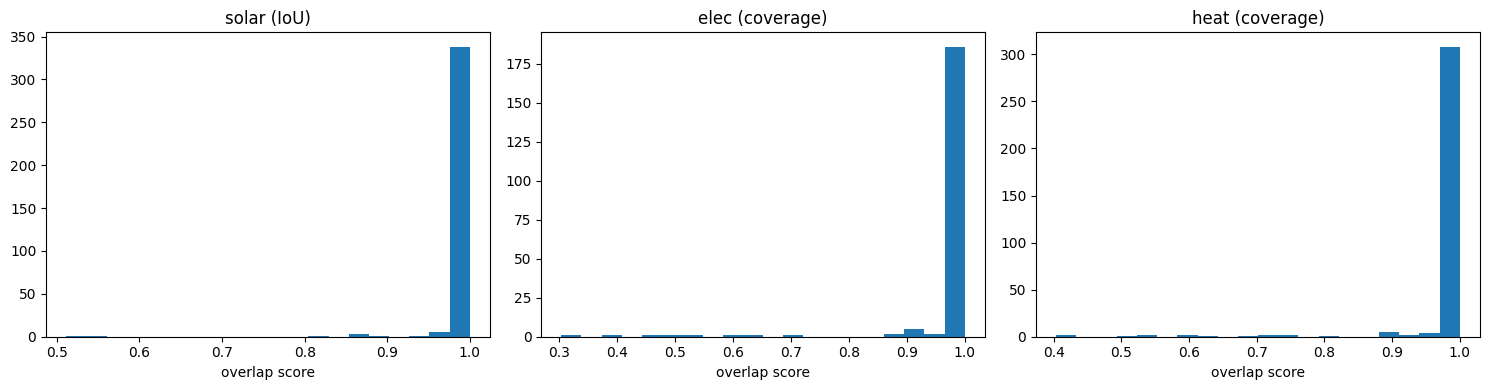

In [18]:
# Overlap-score distribution per dataset - useful for sanity-checking / tuning the min_iou / min_coverage thresholds above.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, matches, name in zip(
    axes,
    [solar_matches, elec_matches, heat_matches],
    ["solar (IoU)", "elec (coverage)", "heat (coverage)"],
):
    ax.hist(matches["score"], bins=20)
    ax.set_title(name)
    ax.set_xlabel("overlap score")
plt.tight_layout()
#plt.show()

Original solar data
                        gml_id  buildingid  \
736   DE.HH.UP_GEBAEUDE_770533       43981   
1856  DE.HH.UP_GEBAEUDE_771627       43340   
2957  DE.HH.UP_GEBAEUDE_772705       42670   
2960  DE.HH.UP_GEBAEUDE_772708       43729   
5203  DE.HH.UP_GEBAEUDE_774890       44017   

                                           eignung  \
736   Eignung 1 (geeignet, sehr hohe Einstrahlung)   
1856  Eignung 1 (geeignet, sehr hohe Einstrahlung)   
2957       Eignung 2 (geeignet, hohe Einstrahlung)   
2960   Eignung 3 (geeignet, mittlere Einstrahlung)   
5203   Eignung 3 (geeignet, mittlere Einstrahlung)   

                                         eignung_t       power   pvarea  \
736   Eignung 1 (geeignet, sehr hohe Einstrahlung)  120.454118  1658.89   
1856  Eignung 1 (geeignet, sehr hohe Einstrahlung)   18.938097   124.19   
2957       Eignung 2 (geeignet, hohe Einstrahlung)    6.081346    37.40   
2960   Eignung 3 (geeignet, mittlere Einstrahlung)    2.124371     5.06   
520

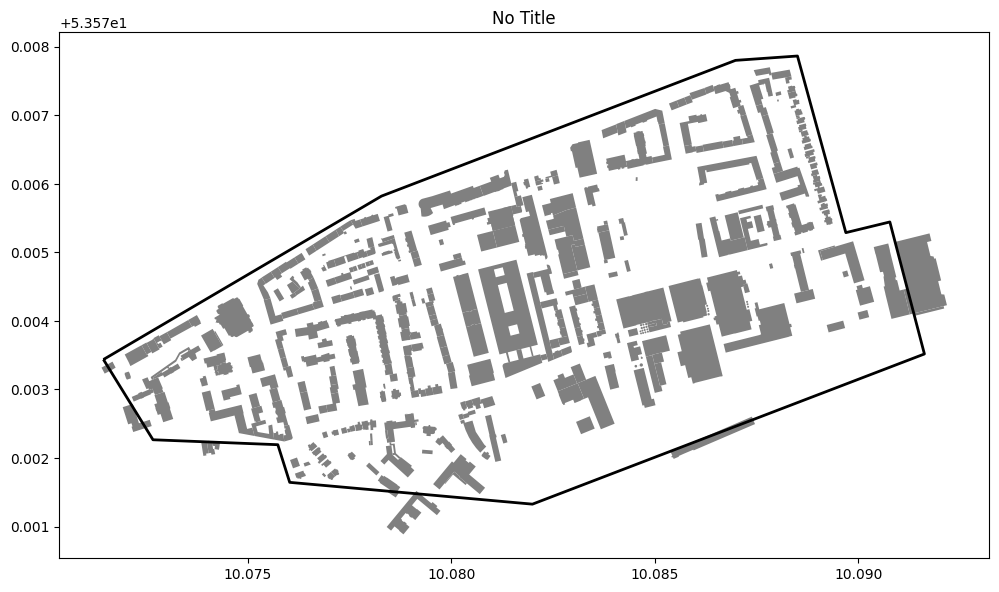

Unmatched (solar): 23


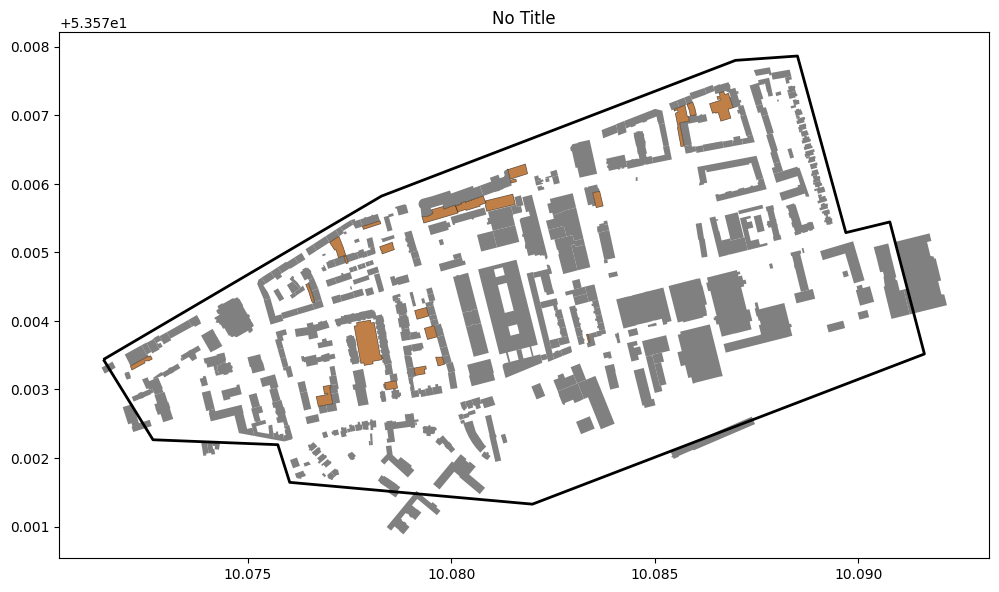

In [19]:
# Visualize buildings that failed to match
unmatched_idx_solar = buildings_m.index.difference(solar_matches["_base_idx"])
unmatched_buildings_solar = buildings_m.loc[unmatched_idx_solar].to_crs("EPSG:4326")
print("Original solar data")
print(limited_solar_gdf.head())
plot(limited_solar_gdf, border_gdf)
print(f"Unmatched (solar): {len(unmatched_buildings_solar)}")
plot(limited_buildings_gdf, border_gdf, unmatched_buildings_solar)

Original electricity data
                               gml_id  nutzflaeche  wohnflaeche  \
21914  DE.HH.UP_STROMVERBRAUCH_613483         2911         2424   
21915  DE.HH.UP_STROMVERBRAUCH_613484         5913         5913   
21916  DE.HH.UP_STROMVERBRAUCH_613485         3153         2354   
21917  DE.HH.UP_STROMVERBRAUCH_613486         2203         2203   
21918  DE.HH.UP_STROMVERBRAUCH_613487         2615         2615   

      enthaelt_heizstrom  stromverbrauch_mw  \
21914                 ja              146.0   
21915               nein               15.0   
21916               nein              135.0   
21917               nein               54.0   
21918               nein               29.0   

                                                geometry  
21914  POLYGON ((10.07095 53.57317, 10.0714 53.57332,...  
21915  POLYGON ((10.07404 53.57266, 10.07405 53.57266...  
21916  POLYGON ((10.07294 53.57366, 10.07289 53.57371...  
21917  POLYGON ((10.07574 53.57306, 10.07575 53.5730

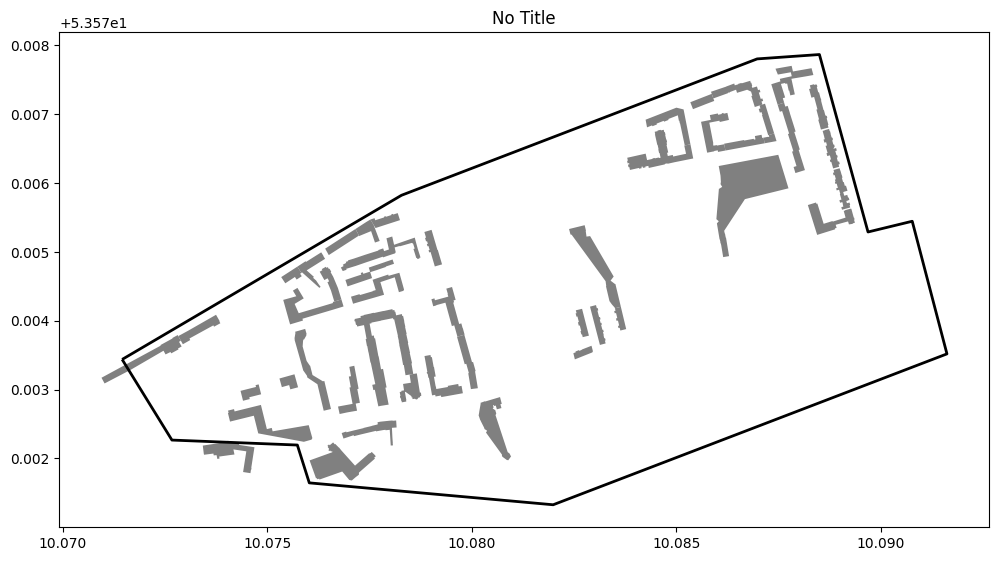

Unmatched (electricity): 171


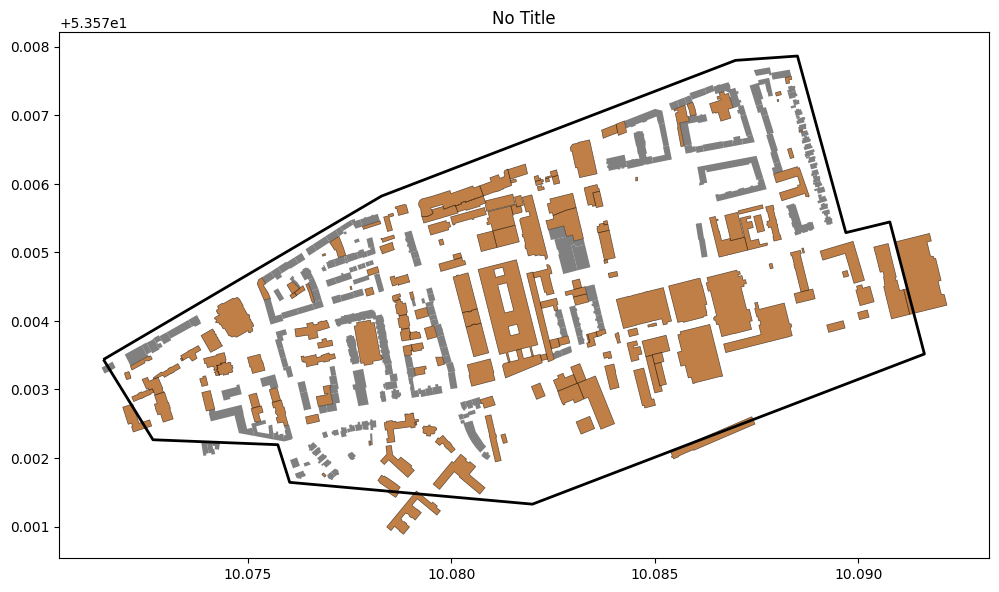

In [20]:
unmatched_idx_elec = buildings_m.index.difference(elec_matches["_base_idx"])
unmatched_buildings_elec = buildings_m.loc[unmatched_idx_elec].to_crs("EPSG:4326")
print("Original electricity data")
print(limited_elec_gdf.head())
plot(limited_elec_gdf, border_gdf)
print(f"Unmatched (electricity): {len(unmatched_buildings_elec)}")
plot(limited_buildings_gdf, border_gdf, unmatched_buildings_elec)

Original heat data
                                    gml_id  anzahl_einheiten  \
1887   DE.HH.UP_NW_ABS_GEB_UNSANIERT_26000                 6   
25696  DE.HH.UP_NW_ABS_GEB_UNSANIERT_25849                 7   
25826  DE.HH.UP_NW_ABS_GEB_UNSANIERT_25850                 5   
25840  DE.HH.UP_NW_ABS_GEB_UNSANIERT_25817                 5   
25841  DE.HH.UP_NW_ABS_GEB_UNSANIERT_25818                 8   

       beheizte_nutzflaeche  beheizte_wohnflaeche  waermebedarf_unsaniert  \
1887                    979                   979                  151158   
25696                  2598                  1234                  299069   
25826                  1187                   403                  129455   
25840                  3272                   951                  296187   
25841                  3066                  1473                  473552   

                                                geometry  
1887   POLYGON ((10.08727 53.57667, 10.08726 53.5767,...  
25696  POLYGON 

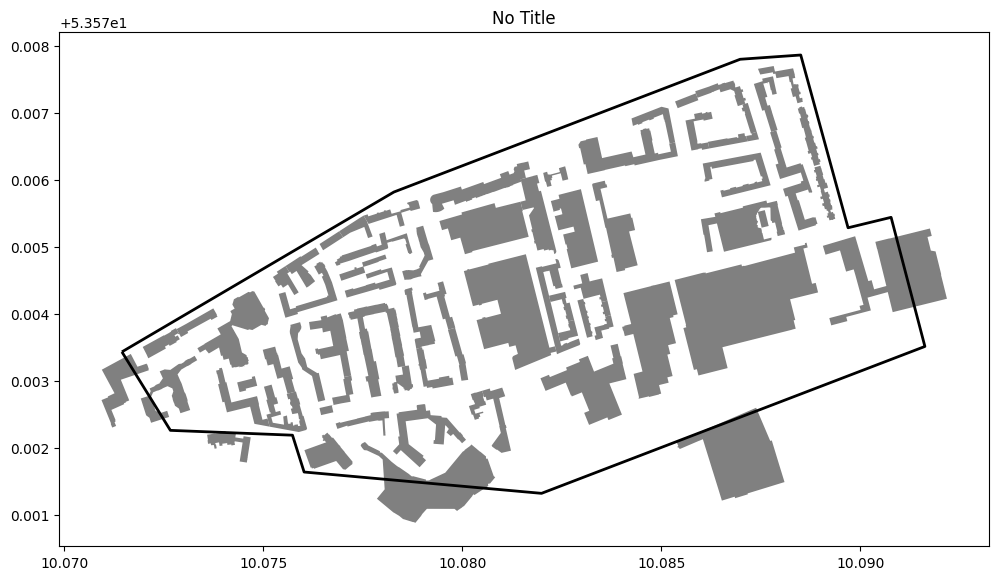

Unmatched (heat): 41


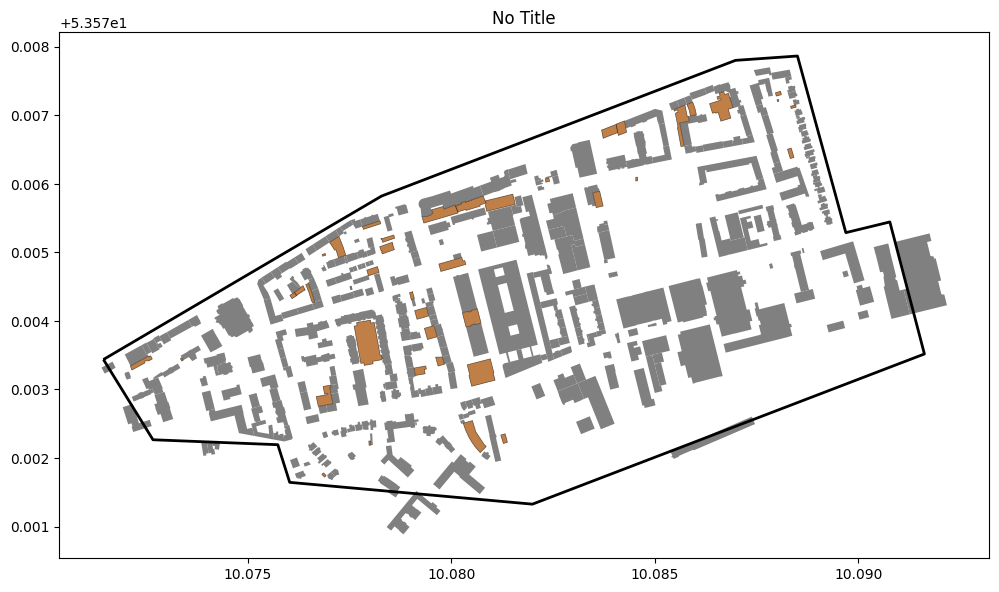

In [21]:
unmatched_idx_heat = buildings_m.index.difference(heat_matches["_base_idx"])
unmatched_buildings_heat = buildings_m.loc[unmatched_idx_heat].to_crs("EPSG:4326")
print("Original heat data")
print(limited_heat_gdf.head())
plot(limited_heat_gdf, border_gdf)
print(f"Unmatched (heat): {len(unmatched_buildings_heat)}")
plot(limited_buildings_gdf, border_gdf, unmatched_buildings_heat)

In [14]:
# Build one row per building with everything available: ALKIS footprint as the base geometry,
# solar/elec/heat attached via the overlap matches above. power/pvarea/stromverbrauch_mw/
# waermebedarf_unsaniert are apportioned whenever a zone is shared by several
# buildings, so per-building values stay additive - summing them over a district reconstructs
# the source totals, which is what makes them trustworthy inputs for later simulation.
buildings_unified = buildings_m.copy()

buildings_unified = attach_match(buildings_unified, solar_matches, solar_m, ["eignung"])
buildings_unified = apportion_value(buildings_unified, solar_matches, solar_m, "power", "_footprint_weight", "solar_power", meta_prefix="solar")
buildings_unified = apportion_value(buildings_unified, solar_matches, solar_m, "pvarea", "_footprint_weight", "solar_pvarea", meta_prefix="solar", include_meta=False)
buildings_unified = apportion_value(buildings_unified, elec_matches, elec_m, "stromverbrauch_mw", "_floor_area_weight", "elec")
buildings_unified = apportion_value(buildings_unified, heat_matches, heat_m, "waermebedarf_unsaniert", "_floor_area_weight", "heat")

print(buildings_unified.shape)
buildings_unified[[
    "identifier", "eignung", "solar_power_value", "solar_pvarea_value", "solar_match_score",
    "elec_value", "elec_n_buildings_in_zone", "elec_match_score",
    "heat_value", "heat_n_buildings_in_zone", "heat_match_score",
]].head(10)

(374, 35)


,identifier,eignung,solar_power_value,solar_pvarea_value,solar_match_score,elec_value,elec_n_buildings_in_zone,elec_match_score,heat_value,heat_n_buildings_in_zone,heat_match_score
0,urn:adv:oid:DEHHALKA70001ttj,"Eignung 2 (geeignet, hohe Einstrahlung)",34.423890,374.98,1.000000,47.270783,5.0,0.465569,1.835772e+05,4.0,1.000000
1,urn:adv:oid:DEHHALKA70001sGw,"Eignung 2 (geeignet, hohe Einstrahlung)",5.329110,47.29,1.000000,NaN,NaN,NaN,3.504944e+04,2.0,0.999998
2,urn:adv:oid:DEHHALKA70001rkX,"Eignung 2 (geeignet, hohe Einstrahlung)",12.210978,106.39,1.000000,24.061254,5.0,0.999973,2.611376e+05,2.0,0.999990
3,urn:adv:oid:DEHHALKA70001sNH,Eignung 6 (geringe Einstrahlung / weniger geei...,0.000000,0.00,1.000000,NaN,NaN,NaN,6.000000e+04,5.0,0.999987
4,urn:adv:oid:DEHHALKAxp000000,"Eignung 2 (geeignet, hohe Einstrahlung)",31.838143,329.29,1.000000,NaN,NaN,NaN,2.646000e+05,5.0,0.999975
5,urn:adv:oid:DEHHALKA70001sEB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,urn:adv:oid:DEHHALKA70001xdR,"Eignung 2 (geeignet, hohe Einstrahlung)",27.270609,163.62,1.000000,NaN,NaN,NaN,3.027503e+04,7.0,1.000000
7,urn:adv:oid:DEHHALKA70001uME,"Eignung 3 (geeignet, mittlere Einstrahlung)",12.271381,73.63,0.974797,17.859987,5.0,0.995979,5.487844e+04,5.0,0.991081
8,urn:adv:oid:DEHHALKA70001sto,"Eignung 2 (geeignet, hohe Einstrahlung)",8.908858,105.91,1.000000,56.253756,3.0,0.997084,2.305572e+05,3.0,0.991932
9,urn:adv:oid:DEHHALKA70001x4H,"Eignung 1 (geeignet, sehr hohe Einstrahlung)",160.508223,2074.11,1.000000,NaN,NaN,NaN,1.340438e+06,7.0,0.999999


## City-wide matching and unified dataset

Same matching, run against the full unfiltered datasets (`buildings_gdf`, `solar_gdf`,
`elec_gdf`, `heat_gdf`) instead of the region subsets, to build one parquet file with
everything known about each of Hamburg's ~382k buildings: footprint/attributes, solar
suitability/power/roof-area, and apportioned electricity/heat demand.

Electricity and heat records each cover a cluster of buildings rather than a single one
(avg. record area is ~3-7x a single building's footprint), so - as above - their values are
apportioned across the matched buildings by estimated floor area rather than copied, and each
row keeps `*_match_score` (how confidently this building belongs to its matched zone) and
`*_n_buildings_in_zone` (how many buildings share that zone). Downstream analysis/simulation
should treat rows with low `*_match_score` or very large `*_n_buildings_in_zone` as less
certain (e.g. filter to `elec_match_score >= 0.5` for a stricter, higher-confidence subset)
rather than trusting every apportioned value equally.

In [ ]:
def unify_datasets(buildings_gdf: gpd.GeoDataFrame, solar_gdf: gpd.GeoDataFrame, elec_gdf: gpd.GeoDataFrame, heat_gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    # Prepare and match datasets, 
    buildings_full_m = buildings_gdf.to_crs("EPSG:25832")
    solar_full_m = solar_gdf.to_crs("EPSG:25832")
    elec_full_m = elec_gdf.to_crs("EPSG:25832")
    heat_full_m = heat_gdf.to_crs("EPSG:25832")
    buildings_full_m["_base_idx"] = buildings_full_m.index

    buildings_full_m["_footprint_weight"] = buildings_full_m["grundflaeche"].fillna(0)
    buildings_full_m["_floor_area_weight"] = buildings_full_m["grundflaeche"].fillna(0) * buildings_full_m["anzahlDerOberirdischenGeschosse"].clip(lower=1).fillna(1)

    print(f"buildings: {len(buildings_full_m)}, solar: {len(solar_full_m)}, elec: {len(elec_full_m)}, heat: {len(heat_full_m)}")

    solar_matches_full = best_iou_match(buildings_full_m, solar_full_m, min_iou=0.3)
    elec_matches_full = best_coverage_match(buildings_full_m, elec_full_m, min_coverage=0.3)
    heat_matches_full = best_coverage_match(buildings_full_m, heat_full_m, min_coverage=0.3)

    match_report(buildings_full_m, solar_matches_full, "solar")
    match_report(buildings_full_m, elec_matches_full, "elec")
    match_report(buildings_full_m, heat_matches_full, "heat")
    

    # Unify the datasets based on the proportional value
    buildings_unified_full = buildings_full_m.copy()

    buildings_unified_full = attach_match(buildings_unified_full, solar_matches_full, solar_full_m, ["eignung"])
    buildings_unified_full = apportion_value(buildings_unified_full, solar_matches_full, solar_full_m, "power", "_footprint_weight", "solar_power", meta_prefix="solar")
    buildings_unified_full = apportion_value(buildings_unified_full, solar_matches_full, solar_full_m, "pvarea", "_footprint_weight", "solar_pvarea", meta_prefix="solar", include_meta=False)
    buildings_unified_full = apportion_value(buildings_unified_full, elec_matches_full, elec_full_m, "stromverbrauch_mw", "_floor_area_weight", "elec")
    buildings_unified_full = apportion_value(buildings_unified_full, heat_matches_full, heat_full_m, "waermebedarf_unsaniert", "_floor_area_weight", "heat")

    # Convenience "safe to use as-is" flags for downstream analysis/simulation - stricter than the
    # min_iou/min_coverage matching threshold (0.3), since a building that's only 30-50% inside its
    # matched zone is a plausible match but a shaky one to build simulation inputs on.
    buildings_unified_full["solar_high_confidence"] = buildings_unified_full["solar_match_score"] >= 0.7
    buildings_unified_full["elec_high_confidence"] = buildings_unified_full["elec_match_score"] >= 0.7
    buildings_unified_full["heat_high_confidence"] = buildings_unified_full["heat_match_score"] >= 0.7

    buildings_unified_full = buildings_unified_full.drop(columns=["_base_idx", "_footprint_weight", "_floor_area_weight"], errors="ignore")

    print(buildings_unified_full.shape)
    buildings_unified_full[[
        "identifier", "solar_power_value", "solar_match_score", "solar_high_confidence",
        "elec_value", "elec_n_buildings_in_zone", "elec_match_score", "elec_high_confidence",
        "heat_value", "heat_n_buildings_in_zone", "heat_match_score", "heat_high_confidence",
    ]].head(10)

    # Coverage summary: how much of the city has each attribute, and how much of that is high-confidence.
    for col, conf_col, name in [
        ("solar_power_value", "solar_high_confidence", "solar"),
        ("elec_value", "elec_high_confidence", "elec"),
        ("heat_value", "heat_high_confidence", "heat"),
    ]:
        has_value = buildings_unified_full[col].notna()
        n = len(buildings_unified_full)
        n_matched = has_value.sum()
        n_high_conf = (has_value & buildings_unified_full[conf_col]).sum()
        print(f"{name}: {n_matched}/{n} ({n_matched/n:.0%}) matched, {n_high_conf}/{n} ({n_high_conf/n:.0%}) high-confidence")

    # save the file
    #buildings_unified_full.to_parquet("buildings_unified.parquet")
    print("Coverage summary")
    print(f"Saved {len(buildings_unified_full)} rows, {len(buildings_unified_full.columns)} columns to buildings_unified.parquet")

    return buildings_unified_full

buildings: 381704, solar: 384908, elec: 39440, heat: 46233


In [23]:
buildings_unified_gdf = gpd.read_parquet("buildings_unified.parquet")

In [24]:
buildings_unified_gdf.head(5)

,identifier,beginnt,advStandardModell,gebaeudefunktion,anzahlDerOberirdischenGeschosse,dachform,grundflaeche,grundflaeche_uom,bauweise,baujahr,...,elec_zone_total,elec_n_buildings_in_zone,elec_match_score,heat_value,heat_zone_total,heat_n_buildings_in_zone,heat_match_score,solar_high_confidence,elec_high_confidence,heat_high_confidence
0,urn:adv:oid:DEHHALKAn0000WjZ,2012-03-28T08:54:41Z,DLKM,2463,1.0,3100.0,60.0,urn:adv:uom:m2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
1,urn:adv:oid:DEHHALKAn0000hoI,2022-05-17T12:06:44Z,DLKM,1010,2.0,3100.0,75.0,urn:adv:uom:m2,1100.0,1995.0,...,40.0,15.0,0.999997,19170.403587,114000.0,8.0,1.000000,True,True,True
2,urn:adv:oid:DEHHALKAn0000Wy3,2012-03-28T08:54:41Z,DLKM,2463,1.0,1000.0,25.0,urn:adv:uom:m2,NaN,NaN,...,23.0,11.0,0.999788,2327.311248,60417.0,11.0,0.999788,True,True,True
3,urn:adv:oid:DEHHALKA41K00003,2018-06-22T04:40:14Z,DLKM,1010,1.0,3200.0,192.0,urn:adv:uom:m2,1100.0,2016.0,...,46.0,7.0,0.999998,21479.254113,122387.0,8.0,0.999997,True,True,True
4,urn:adv:oid:DEHHALKAn0000i8m,2012-03-28T08:54:41Z,DLKM,2140,1.0,1000.0,115.0,urn:adv:uom:m2,NaN,NaN,...,NaN,NaN,NaN,58485.074850,509583.0,5.0,0.999999,True,False,True


In [38]:
inspection_area = [[10.071450882096563, 53.57343719771864],
               [10.078282200812708, 53.57582089436743],
               [10.086978353249249, 53.57780085497406],
               [10.088500780178016, 53.57786434031859],
               [10.08968943613927, 53.57528776626812],
               [10.090770539267197, 53.57544358156409],
               [10.09161951641922, 53.57351782519276],
               [10.081990170144394, 53.57132713390438],
                [10.07602700765947, 53.571645156140086],
                [10.07573490367003, 53.5721943741919],
                [10.072668065541466, 53.57226654319956]]


ToDo:

Stewen Lehmann
LPG Austausch:
1. Kann man von GIS-Daten Profile erzeugen?
2. wie funktioniert das Tool

Beispiel MFH 4-5 Familien 3-4 Stockwerke
Basis Profile gebraucht